# **Fine-Tuning of a YOLO26 Model and its metrics**

The main objective of this notebook is the *fine-tuning* of a **YOLOv26 Small** model for the task of Argentine ID-Card elements detection. After that, calculate the metrics of *fine-tuned* model against our *test* set.

## **Training Plan**
1. Fine-Tuned the **small** version of (`yolo26s.pt`).
2. Evaluate against the **test** split.

## **Expected Input:**

* Dataset ready for train.
* Small version of **YOLO** model.

# **Expected Output:**

* *Fine-tuned* model for this task.
* Metrics

## **Libraries and Settings**


In [6]:
from ultralytics import YOLO
import ultralytics
import os
import torch
import fiftyone as fo
import matplotlib.pyplot as plt
import shutil
import cv2

if not os.environ.get("BASE_PROJECT_DIR"):
    os.environ["BASE_PROJECT_DIR"] = input("Enter the base project directory path: ")

MODEL_PATH_SMALL = f"{os.getenv('BASE_PROJECT_DIR')}/weights/yolo/yolo26s.pt"
DS_NAME = "ds_arg_ID_card_elements_v1"
DS_DIR = f"{os.getenv('BASE_PROJECT_DIR')}/data/ds/{DS_NAME}"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TRAIN_CFG = dict(
    epochs=100,
    imgsz=1216,
    batch=2,
    nbs=8,        
    lr0=0.01,
    patience=25,
    device=DEVICE,
    seed=42,
    amp=True,
    workers=4,
    cache=False,
)
CLASSES = ["picture", "shield", "doc_number", "tramite_number", "pdf_417", "mrz", "address", "gender", "country"]
print(f"FiftyOne version: {fo.__version__}")
print(f"Ultralytics version: {ultralytics.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Device: {DEVICE}")

FiftyOne version: 1.21.0
Ultralytics version: 8.4.117
PyTorch version: 2.13.0+cu130
Matplotlib version: 3.11.0
Device: cuda


* Load our dataset

In [3]:
dataset = fo.load_dataset(DS_NAME)
dataset

Name:        ds_arg_ID_card_elements_v1
Media type:  image
Num samples: 322
Persistent:  True
Tags:        []
Sample fields:
    id:                 fiftyone.core.fields.ObjectIdField
    filepath:           fiftyone.core.fields.StringField
    tags:               fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:           fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:         fiftyone.core.fields.DateTimeField
    last_modified_at:   fiftyone.core.fields.DateTimeField
    ground_truth:       fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    predictions:        fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    eval_yolo_small_tp: fiftyone.core.fields.IntField
    eval_yolo_small_fp: fiftyone.core.fields.IntField
    eval_yolo_small_fn: fiftyone.core.fields.IntField

## **Fine-tuning of YOLO Model**

Now, make the *fine-tuning* of our **YOLO** model for our task.

First load our *pretrained* model and make the *fine-tuning*.

In [7]:
assert os.path.exists(MODEL_PATH_SMALL)
model = YOLO(model=MODEL_PATH_SMALL)

In [15]:
assert os.path.exists(DS_DIR+"/dataset.yaml")
result = model.train(
    data=DS_DIR+"/dataset.yaml",
    # project="runs",
    name="small",
    **TRAIN_CFG
)

New https://pypi.org/project/ultralytics/8.4.138 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3080 Laptop GPU, 7840MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/nahuel/Documentos/Python/DNI/data/ds/ds_arg_ID_card_elements_v1/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1216, iou=0.7, keras=False, kobj=1.0, line_

* Copy our *fine-tuned* model to our `weights` directory in the `root` of the project.

In [ ]:
best_model = result.save_dir / "weights" / "best.pt"
to_path = os.getenv('BASE_PROJECT_DIR') + "/weights/yolo/yolo26s_ID_elements_det.pt"
shutil.copy(best_model, to_path)

## **Calculate Metrics against our `test` set**

### **Evaluation Pipeline**

1. Load our fine-tuned model.
2. Run inference on each test sample.
3. Call `evaluate_detections()` on the test view.
4. Report **Precision**, **Recall**, **F1-Score** per class and overall **mAP@50**.

### **Expected Output**

* Per-class **Precision** / **Recall** / **F1** table.

In [29]:
def calculate_metrics(model: YOLO,
                      ds: fo.Dataset,
                      label_field: str,
                      eval_name: str,
                      iou: float = 0.5,
                      compute_mAP: bool = True) -> fo.utils.eval.coco.COCODetectionResults:
    model = YOLO(model=model)
    test_view = ds.match_tags("test")
    test_view.apply_model(model=model,
                          label_field=label_field,
                          confidence_thresh=0.5)

    metrics = test_view.evaluate_detections(
        label_field,
        gt_field="ground_truth",
        eval_key=eval_name,
        eval_iou=iou,
        compute_mAP=compute_mAP)
    return metrics

### **Example of inference**


image 1/1 /home/nahuel/Documentos/Python/DNI/data/prc/ds_arg_ID_card_elements_v1/images/2163_0.png: 768x1216 1 mrz, 1 address, 1 country, 10.2ms
Speed: 29.5ms preprocess, 10.2ms inference, 1.0ms postprocess per image at shape (1, 3, 768, 1216)


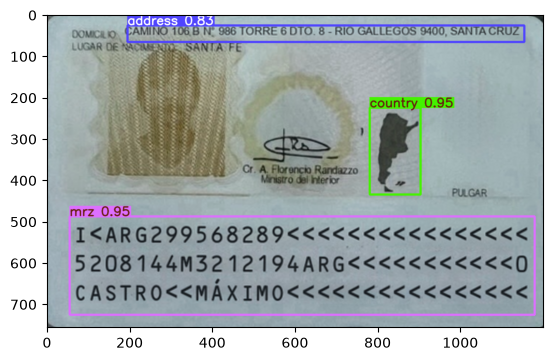

In [7]:
IMG_PATH = "/home/nahuel/Documentos/Python/DNI/data/prc/ds_arg_ID_card_elements_v1/images/2163_0.png"

fine_tuned_model = f"{os.environ.get('BASE_PROJECT_DIR')}/weights/yolo/yolo26s_ID_elements_det.pt"
yolo_model = YOLO(fine_tuned_model)

result = yolo_model.predict(IMG_PATH)[0]
plt.imshow(result.plot())
plt.show()

* Calculate metrics for our model.

In [ ]:
metrics = calculate_metrics(model=fine_tuned_model,
                            ds=dataset,
                            label_field="predictions",
                            eval_name="eval_yolo_small",
                            iou=0.5,
                            compute_mAP=True)

In [26]:
print(metrics.print_report())
print(metrics.print_metrics())  

                precision    recall  f1-score   support

       address       1.00      1.00      1.00        11
       country       1.00      0.91      0.95        11
    doc_number       1.00      0.95      0.98        21
        gender       0.94      0.81      0.87        21
           mrz       1.00      1.00      1.00        11
       pdf_417       1.00      1.00      1.00        21
       picture       1.00      1.00      1.00        21
        shield       1.00      0.95      0.98        21
tramite_number       1.00      0.90      0.95        21

     micro avg       0.99      0.94      0.97       159
     macro avg       0.99      0.95      0.97       159
  weighted avg       0.99      0.94      0.97       159

None
accuracy   0.94
precision  0.99
recall     0.94
fscore     0.97
support    159
None


## **Conclusions**

### Summary of results on the `test` split

